# CS2 Economy Clustering

In [1]:
#imports 
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler, RobustScaler #Standard Scaler seemed less impactful 
from sklearn.metrics import silhouette_score
from math import pi
import matplotlib.pyplot as plt
import polars as pl
import numpy as np
import pandas as pd
import seaborn as sns

### read parsed data file

In [2]:

pl.enable_string_cache() # need this to pair values together between training and test sets

In [3]:
df = pl.read_parquet("all_cs2_majors_econ_data.parquet")

In [4]:
df.head(5)

match_id,round,total_rounds_played,player_name,current_equip_value,balance,armor_value,has_helmet,has_defuser,inventory,team_num,winner
str,f64,f64,str,f64,f64,f64,bool,bool,list[str],f64,str
"""ecstatic-vs-themongolz-nuke""",1.0,0.0,"""salazar""",850.0,150.0,100.0,false,false,"[""Butterfly Knife"", ""USP-S""]",3.0,"""UNKNOWN"""
"""ecstatic-vs-themongolz-nuke""",1.0,0.0,"""mzinho""",850.0,150.0,100.0,false,false,"[""Butterfly Knife"", ""Glock-18""]",2.0,"""UNKNOWN"""
"""ecstatic-vs-themongolz-nuke""",1.0,0.0,"""Senzu""",850.0,150.0,100.0,false,false,"[""Bayonet"", ""Glock-18""]",2.0,"""UNKNOWN"""
"""ecstatic-vs-themongolz-nuke""",1.0,0.0,"""Techno""",850.0,150.0,100.0,false,false,"[""Butterfly Knife"", ""Glock-18"", ""C4 Explosive""]",2.0,"""UNKNOWN"""
"""ecstatic-vs-themongolz-nuke""",1.0,0.0,"""910""",1350.0,150.0,100.0,false,false,"[""M9 Bayonet"", ""Glock-18"", … ""Flashbang""]",2.0,"""UNKNOWN"""


#### remove first round of each half

In [5]:
df = df.filter(pl.col("round") != 1.0)
df = df.filter(pl.col("round") != 13.0)

#### one hot encode inventory

In [6]:
#get uniique item list to parse for releevant items
unique_items = (
    df.select("inventory")
    .explode("inventory")
    .unique()
    .sort("inventory"))

items_list = unique_items["inventory"].to_list()
print(items_list)

[None, 'AK-47', 'AUG', 'AWP', 'Bayonet', 'Bowie Knife', 'Butterfly Knife', 'C4 Explosive', 'CZ75-Auto', 'Classic Knife', 'Decoy Grenade', 'Desert Eagle', 'Dual Berettas', 'FAMAS', 'Falchion Knife', 'Five-SeveN', 'Flashbang', 'Flip Knife', 'Galil AR', 'Glock-18', 'Gut Knife', 'High Explosive Grenade', 'Huntsman Knife', 'Incendiary Grenade', 'Karambit', 'Kukri Knife', 'M4A1-S', 'M4A4', 'M9 Bayonet', 'MAC-10', 'MAG-7', 'MP5-SD', 'MP7', 'MP9', 'Molotov', 'Navaja Knife', 'Nomad Knife', 'Nova', 'P2000', 'P250', 'P90', 'Paracord Knife', 'R8 Revolver', 'SG 553', 'SSG 08', 'Shadow Daggers', 'Skeleton Knife', 'Smoke Grenade', 'Stiletto Knife', 'Survival Knife', 'Talon Knife', 'Tec-9', 'UMP-45', 'USP-S', 'Ursus Knife', 'XM1014', 'Zeus x27', 'knife', 'knife_t']


In [7]:
#pull out relevant items to list, some items are cosmetics which don't effect performance
relevant_items = ['AK-47', 'AUG', 'AWP', 'Decoy Grenade', 'Desert Eagle', 'Dual Berettas', 'FAMAS', 
                  'Five-SeveN', 'Flashbang', 'Galil AR', 'Glock-18', 'High Explosive Grenade', 
                  'Incendiary Grenade', 'M4A1-S', 'M4A4', 'MAC-10', 'MAG-7', 'MP5-SD', 'MP7', 'MP9', 
                  'Molotov', 'Nova', 'P2000', 'P250', 'P90', 'R8 Revolver', 'SG 553', 'SSG 08', 
                  'Smoke Grenade',   'Tec-9', 'UMP-45', 'USP-S', 'XM1014', 'Zeus x27']
df = df.with_columns([
    pl.col("inventory").list.contains(item)
    .cast(pl.Int8).alias(item)
    for item in relevant_items])

In [8]:
# replace team_num with something simpler, CT = 1, T=0
df = df.with_columns(pl.col("team_num").replace({3.0: 1, 2.0: 0}).cast(pl.Int8).alias("team_num"))
# replace winner with similar values, setting corrupted rows to 99
df = df.with_columns(pl.col("winner").replace({"CT": 1, "T": 0, "UNKNOWN": 99}).fill_null(99).cast(pl.Int8))

In [9]:
#drop player name and inventory cause we don't need the former and expanded the latter
df = df.drop(["player_name", "inventory"])

In [10]:
# match id is an awkward string, but it's useful for grouping by game
# we'll turn this categorical variable into a simpler numeric representation and keep a reference df to make the connection simpler
df = df.with_columns(pl.col("match_id").cast(pl.Categorical))

match_reference = (
    df.select("match_id")
    .unique()
    .with_columns(id_value = pl.col("match_id").to_physical())
    .select(["id_value", "match_id"])
    .sort("id_value"))


df = df.with_columns(pl.col("match_id").to_physical())

In [11]:
match_reference.head()

id_value,match_id
u32,cat
0,"""ecstatic-vs-themongolz-nuke"""
1,"""imperial-vs-metizport-m2-dust2"""
2,"""legacy-vs-red-canids-nuke"""
3,"""liquid-vs-b8-mirage"""
4,"""mouz-vs-spirit-m2-train"""


In [12]:
#clean up column names so they're less annoying
df = df.rename({
    col: col.lower().replace(" ", "_").replace("-", "_") 
    for col in df.columns
})

In [13]:
# create lists for certain weapon/equipment categories categories
awp = ['awp']
full_rifles = ['ak_47', 'm4a1_s', 'm4a4', 'aug', 'sg_553']
half_rifles = ['galil_ar', 'famas', 'ssg_08']
smgs = ['mp9', 'mp7', 'ump_45', 'p90', 'mac_10',  'mp5_sd', 'nova']
shotguns = ['xm1014','mag_7','nova']
poor_buys = ['p250', 'desert_eagle', 'dual_berettas', 'five_seven', 'tec_9', 'r8_revolver', 'zeus_x27']
utility_buys = ['flashbang', 'smoke_grenade', 'high_explosive_grenade', 'molotov', 'incendiary_grenade', 'decoy_grenade']
base_weapons = ['glock_18', 'usp_s', 'p2000']
equipment_columns = [
    'ak_47', 'aug', 'awp', 'decoy_grenade', 'desert_eagle', 'dual_berettas',
    'famas', 'five_seven', 'flashbang', 'galil_ar', 'glock_18',
    'high_explosive_grenade', 'incendiary_grenade', 'm4a1_s', 'm4a4', 'mac_10',
    'mag_7', 'mp5_sd', 'mp7', 'mp9', 'molotov', 'nova', 'p2000', 'p250', 'p90',
    'r8_revolver', 'sg_553', 'ssg_08', 'smoke_grenade', 'tec_9', 'ump_45',
    'usp_s', 'xm1014', 'zeus_x27', 'armor_value', 'has_helmet', 'has_defuser']

In [14]:
number_of_unknown_rounds = df.filter(pl.col("winner")==99).height
known_rounds = df.filter(pl.col("winner")!=99).height

In [15]:
print("total unknown winning rounds ", number_of_unknown_rounds)
print("total rounds with a winner ", known_rounds)
print(f" {round((number_of_unknown_rounds/known_rounds)*100, 2)}% of rounds have an unlabeled winner")

total unknown winning rounds  880
total rounds with a winner  112445
 0.78% of rounds have an unlabeled winner


In [16]:
train_df = df.filter(pl.col("winner") != 99) # filter unknown winners
train_df = train_df.drop_nulls(subset=["team_num"]) #remove null rows (seemingly botched from the demo)


In [17]:
#combine individual players into counts per team
team_stats = train_df.group_by(["match_id", "round", "team_num", "winner"]).agg([
    pl.col("current_equip_value").sum().alias("total_equip_val"),
    pl.col("balance").sum().alias("total_bank"),
    pl.col("armor_value").mean().alias("avg_armor"),
    pl.col("has_helmet").sum().alias("helmet_count"),
    pl.col("has_defuser").sum().alias("kit_count"),
    pl.col(awp).sum().alias("awp_count"),
    pl.sum_horizontal(pl.col(full_rifles)).sum().alias("rifle_count"),
    pl.sum_horizontal(pl.col(utility_buys)).sum().alias("total_util"),
    pl.sum_horizontal(pl.col(half_rifles)).sum().alias("half_rifle_count"),
    pl.sum_horizontal(pl.col(smgs)).sum().alias("small_buy_count"),
    pl.sum_horizontal(pl.col(shotguns)).sum().alias("shotgun_buy_count"),
    pl.sum_horizontal(pl.col(poor_buys)).sum().alias("upg_pst")])

In [18]:
# split by side
t_stats = team_stats.filter(pl.col("team_num") == 0)
ct_stats = team_stats.filter(pl.col("team_num") == 1)

In [19]:
# First Model, KMeans Cluster for Novel Strategies
def km_analyze_side(df, side_name, n_clusters=10):

    buy_features = [
        'total_bank', 
        'avg_armor', 'helmet_count', 'kit_count', 
        'awp_count', 'rifle_count', 'total_util', 'half_rifle_count', 
        'small_buy_count','shotgun_buy_count', 'upg_pst'] #selected features for domain knowledge

    X = df.select(buy_features).to_numpy()
    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X)
    
    kmeans = KMeans(n_clusters=n_clusters, n_init=20)
    kmeans.fit(X_scaled)

    real_centers = scaler.inverse_transform(kmeans.cluster_centers_)
    centroids_df = (pl.DataFrame(real_centers, schema=buy_features, orient="row").with_row_index(name="cluster_id"))
    
    labeled_df = df.with_columns([pl.Series(name="cluster_id", values=kmeans.labels_), (pl.col("team_num") == pl.col("winner")).alias("won_round")])

    report = (
        labeled_df.group_by("cluster_id")
        .agg([
            pl.len().alias("times_used"),
            pl.mean("won_round").alias("win_rate")])
        .join(centroids_df, on="cluster_id", how="left")
        .sort("win_rate", descending=True))
    
    print(f"\n=== {side_name} ===")
    print(f"{'ID':<3} | {'Win %':<6} | {'Used':<5} | {'Bank':<9} | {'Armor':<5} | {'Awps':<4} | {'Rifles':<6} | {'Half-R':<6} | {'Smalls':<6} | {'Shotguns':<7} | {'Pistols':<7} | {'Util':<5} | {'Kits':<4} | {'Helmets'}")

    for row in report.iter_rows(named=True):
        cid = row['cluster_id']
        wr = row['win_rate'] * 100
        count = row['times_used']
        bank = row['total_bank']
        armor = row['avg_armor']
        awps = row['awp_count']
        rifles = row['rifle_count']
        half_rifles = row['half_rifle_count']
        smalls = row['small_buy_count']
        shotguns = row['shotgun_buy_count']
        poors = row['upg_pst']
        util = row['total_util']
        kits = row['kit_count']
        helmets = row['helmet_count']
        
        print(f"{cid:<3} | {wr:>4.1f}   | {count:<5} | {bank:<5.0f}    | {armor:<5.1f} | {awps:<4.1f} | {rifles:<6.1f} | {half_rifles:<6.1f} | {smalls:<6.1f} | {shotguns:>7.1f} | {poors:<7.1f} | {util:<5.1f} | {kits:<4.1f} | {helmets:.1f}")

    score = silhouette_score(X_scaled, kmeans.labels_)
    print(f"\nK-Means Silhouette Score: {score:.3f}")
    return report, labeled_df

In [20]:
t_report, t_labeled = km_analyze_side(t_stats, "TERRORIST")
ct_report, ct_labeled = km_analyze_side(ct_stats, "COUNTER-TERRORIST")


=== TERRORIST ===
ID  | Win %  | Used  | Bank      | Armor | Awps | Rifles | Half-R | Smalls | Shotguns | Pistols | Util  | Kits | Helmets
7   | 95.4   | 1020  | 16733    | 80.6  | 0.4  | 4.2    | 0.2    | 0.1    |    -0.0 | 0.8     | 17.8  | 0.0  | 4.9
3   | 85.3   | 1439  | 27850    | 93.2  | 0.8  | 4.2    | 0.0    | 0.1    |    -0.0 | 1.2     | 17.8  | 0.0  | 5.0
9   | 74.6   | 778   | 4403     | 97.6  | 0.1  | 1.8    | 1.0    | 1.8    |    -0.0 | 0.7     | 14.5  | 0.0  | 5.0
5   | 54.9   | 1485  | 3568     | 97.1  | 0.1  | 1.6    | 2.6    | 0.4    |    -0.0 | 0.6     | 13.3  | 0.0  | 4.8
1   | 50.8   | 2137  | 6865     | 97.0  | 1.0  | 3.7    | 0.1    | 0.0    |    -0.0 | 0.6     | 16.2  | 0.0  | 4.9
8   | 33.1   | 2162  | 3822     | 98.3  | 0.0  | 4.5    | 0.3    | 0.1    |     0.0 | 0.3     | 15.0  | 0.0  | 5.0
4   |  3.7   | 673   | 3274     | 94.1  | 0.1  | 0.8    | 0.5    | 0.2    |    -0.0 | 3.3     | 8.6   | 0.0  | 3.8
0   |  2.0   | 796   | 10226    | 3.7   | 0.0  | 0.1   

In [21]:
# using agglomerate clustering to reenforce previous work
def agg_analyze_side(df, side_name, n_clusters=None, distance_threshold=75.0):

    buy_features = ['total_bank', 'avg_armor', 'helmet_count', 'kit_count', 
        'awp_count', 'rifle_count', 'total_util', 'half_rifle_count', 
        'small_buy_count','shotgun_buy_count', 'upg_pst']

    X = df.select(buy_features).to_numpy()
    scaler = RobustScaler() 
    X_scaled = scaler.fit_transform(X)

    agg = AgglomerativeClustering(
        n_clusters=n_clusters, # instead of defining the number we want to see if there's a distance we can utilize to reach meta game standards
        distance_threshold=distance_threshold, 
        linkage='ward')

    labels = agg.fit_predict(X_scaled)

    labeled_df = df.with_columns([
        pl.Series(name="cluster_id", values=labels),
        (pl.col("team_num") == pl.col("winner")).alias("won_round")])

    centroids_df = (
        labeled_df.group_by("cluster_id")
        .agg([pl.mean(col) for col in buy_features]))
    
    report = (
        labeled_df.group_by("cluster_id")
        .agg([
            pl.len().alias("times_used"),
            pl.mean("won_round").alias("win_rate")])
        .join(centroids_df, on="cluster_id", how="left")
        .sort("win_rate", descending=True))
    

    print(f"\n=== {side_name} (Agglomerative, Found Clusters: {agg.n_clusters_}) ===")
    print(f"{'ID':<3} | {'Win %':<6} | {'Used':<5} | {'Bank':<9} | {'Armor':<5} | {'Awps':<4} | {'Rifles':<6} | {'Half-R':<6} | {'Smalls':<6} | {'Shotguns':<7} | {'Pistols':<7} | {'Util':<5} | {'Kits':<4} | {'Helmets'}")

    for row in report.iter_rows(named=True):
        cid = row['cluster_id']
        wr = row['win_rate'] * 100
        count = row['times_used']
        bank = row['total_bank']
        armor = row['avg_armor']
        awps = row['awp_count']
        rifles = row['rifle_count']
        half_rifles = row['half_rifle_count']
        smalls = row['small_buy_count']
        shotguns = row['shotgun_buy_count']
        poors = row['upg_pst']
        util = row['total_util']
        kits = row['kit_count']
        helmets = row['helmet_count']
        
        print(f"{cid:<3} | {wr:>4.1f}   | {count:<5} | {bank:<5.0f}    | {armor:<5.1f} | {awps:<4.1f} | {rifles:<6.1f} | {half_rifles:<6.1f} | {smalls:<6.1f} | {shotguns:>7.1f} | {poors:<7.1f} | {util:<5.1f} | {kits:<4.1f} | {helmets:.1f}")

    score = silhouette_score(X_scaled, labels)
    print(f"\nAgglomerative Silhouette Score: {score:.3f}")
    return report, labeled_df

In [22]:
t_report, t_labeled = agg_analyze_side(t_stats, "TERRORIST")
ct_report, ct_labeled = agg_analyze_side(ct_stats, "COUNTER-TERRORIST")


=== TERRORIST (Agglomerative, Found Clusters: 6) ===
ID  | Win %  | Used  | Bank      | Armor | Awps | Rifles | Half-R | Smalls | Shotguns | Pistols | Util  | Kits | Helmets
4   | 86.5   | 1782  | 25023    | 89.0  | 0.7  | 4.3    | 0.0    | 0.0    |     0.0 | 1.3     | 17.9  | 0.0  | 5.0
0   | 70.0   | 2268  | 5373     | 96.4  | 0.1  | 1.9    | 2.0    | 0.8    |     0.0 | 0.7     | 14.5  | 0.0  | 4.9
3   | 46.0   | 4916  | 6507     | 96.4  | 0.5  | 4.1    | 0.2    | 0.1    |     0.0 | 0.5     | 15.6  | 0.0  | 4.9
2   |  4.3   | 771   | 3074     | 93.4  | 0.0  | 0.7    | 0.8    | 0.3    |     0.0 | 3.0     | 8.4   | 0.0  | 3.7
5   |  2.0   | 796   | 10226    | 3.7   | 0.0  | 0.1    | 0.1    | 0.0    |     0.0 | 1.5     | 0.8   | 0.0  | 0.1
1   |  1.7   | 691   | 7558     | 70.8  | 0.1  | 0.4    | 0.2    | 0.1    |     0.0 | 3.5     | 5.6   | 0.0  | 1.2

Agglomerative Silhouette Score: 0.271

=== COUNTER-TERRORIST (Agglomerative, Found Clusters: 6) ===
ID  | Win %  | Used  | Bank      |

In [23]:
def agg_sensitivity_analysis(df, side_name):
    buy_features = ['total_bank', 'avg_armor', 'helmet_count', 'kit_count', 
        'awp_count', 'rifle_count', 'total_util', 'half_rifle_count', 
        'small_buy_count','shotgun_buy_count', 'upg_pst']
    
    X = df.select(buy_features).to_numpy()
    X_scaled = RobustScaler().fit_transform(X)
    
    thresholds = [50, 60, 70, 75, 80, 90, 100, 120]
    
    print(f"\n=== Sensitivity Analysis: {side_name} (Agglomerative) ===")
    print(f"{'Threshold':<10} | {'Clusters Formed':<15} | {'Silhouette Score'}")
    print("-" * 50)
    
    for t in thresholds:
        agg = AgglomerativeClustering(n_clusters=None, distance_threshold=t, linkage='ward')
        labels = agg.fit_predict(X_scaled)
        
        if agg.n_clusters_ > 1:
            sil_score = silhouette_score(X_scaled, labels)
            print(f"{t:<10} | {agg.n_clusters_:<15} | {sil_score:.3f}")
        else:
            print(f"{t:<10} | {agg.n_clusters_:<15} | N/A (1 cluster)")

In [24]:
agg_sensitivity_analysis(t_stats, "TERRORIST")


=== Sensitivity Analysis: TERRORIST (Agglomerative) ===
Threshold  | Clusters Formed | Silhouette Score
--------------------------------------------------
50         | 9               | 0.206
60         | 6               | 0.271
70         | 6               | 0.271
75         | 6               | 0.271
80         | 5               | 0.257
90         | 5               | 0.257
100        | 4               | 0.326
120        | 4               | 0.326


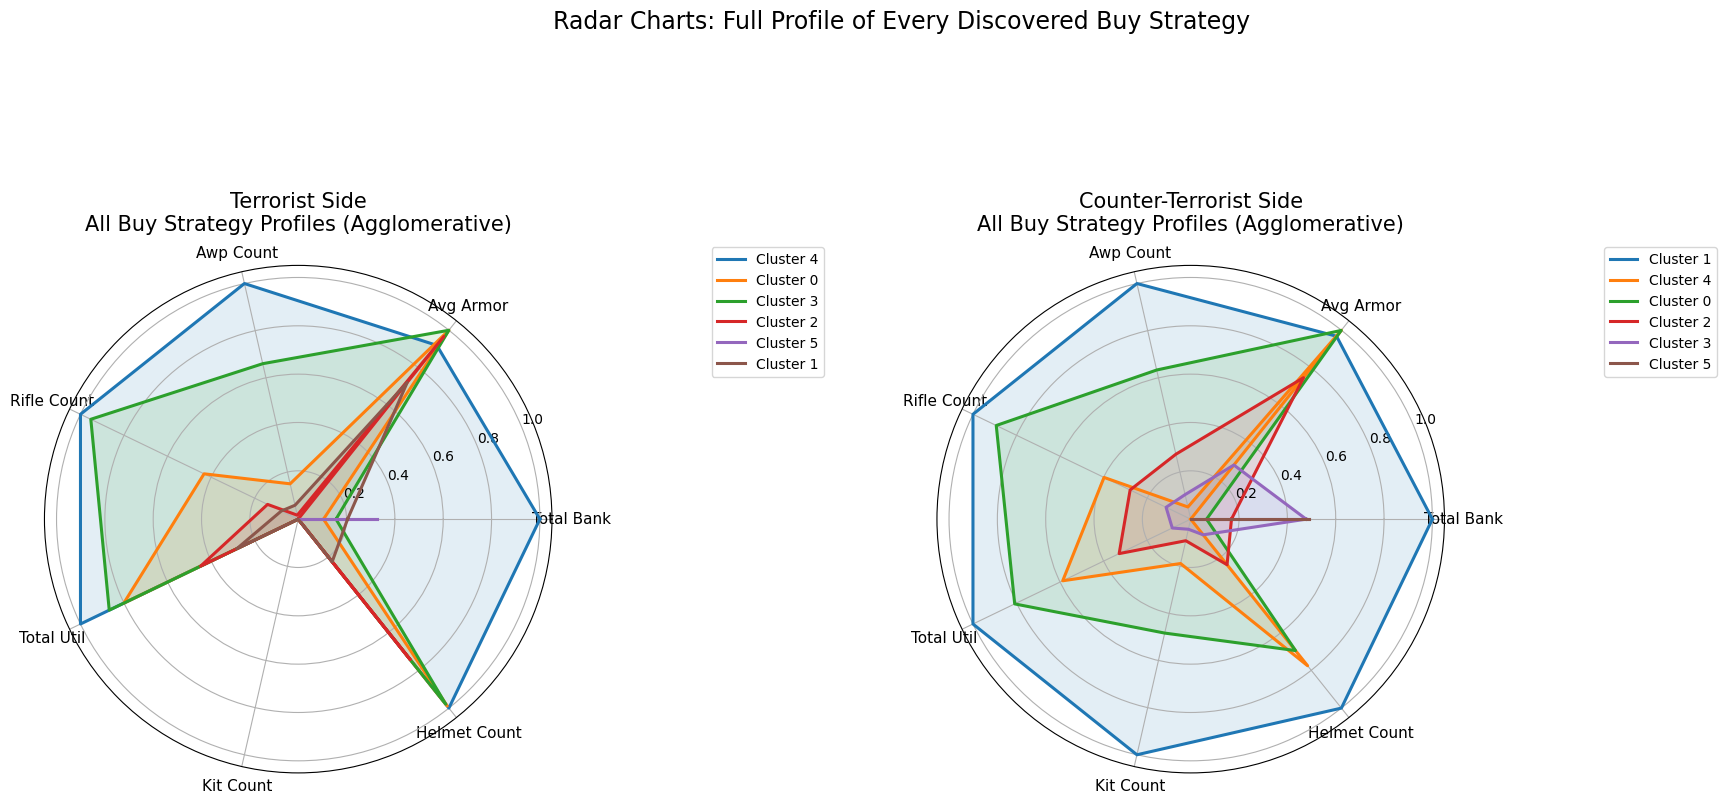

In [25]:
def plot_radar_all_clusters(t_report_agg, ct_report_agg):
    features = ['total_bank', 'avg_armor', 'awp_count', 'rifle_count', 
                'total_util', 'kit_count', 'helmet_count']
    
    # Use ALL clusters (sorted exactly as in your report table)
    t_all = t_report_agg.to_pandas()   # already sorted by win_rate descending
    ct_all = ct_report_agg.to_pandas()
    
    # Normalize 0-1 scale
    t_norm = t_all[features].apply(lambda x: (x - x.min()) / (x.max() - x.min() + 1e-8), axis=0)
    ct_norm = ct_all[features].apply(lambda x: (x - x.min()) / (x.max() - x.min() + 1e-8), axis=0)
    
    categories = [f.replace('_', ' ').title() for f in features]
    N = len(categories)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    
    fig, axs = plt.subplots(1, 2, figsize=(18, 9), subplot_kw=dict(polar=True))
    
    # Terrorist Side - All Clusters
    ax = axs[0]
    for idx, row in t_norm.iterrows():
        values = row.tolist() + row.tolist()[:1]
        cluster_id = t_all['cluster_id'].iloc[idx]   # Use exact cluster_id from table
        ax.plot(angles, values, linewidth=2.2, linestyle='solid', 
                label=f"Cluster {cluster_id}")
        ax.fill(angles, values, alpha=0.12)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=11)
    ax.set_title("Terrorist Side\nAll Buy Strategy Profiles (Agglomerative)", fontsize=15, pad=25)
    ax.legend(loc='upper right', bbox_to_anchor=(1.55, 1.05), fontsize=10)
    
    # Counter-Terrorist Side - All Clusters
    ax = axs[1]
    for idx, row in ct_norm.iterrows():
        values = row.tolist() + row.tolist()[:1]
        cluster_id = ct_all['cluster_id'].iloc[idx]
        ax.plot(angles, values, linewidth=2.2, linestyle='solid', 
                label=f"Cluster {cluster_id}")
        ax.fill(angles, values, alpha=0.12)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=11)
    ax.set_title("Counter-Terrorist Side\nAll Buy Strategy Profiles (Agglomerative)", fontsize=15, pad=25)
    ax.legend(loc='upper right', bbox_to_anchor=(1.55, 1.05), fontsize=10)
    
    plt.suptitle("Radar Charts: Full Profile of Every Discovered Buy Strategy", fontsize=17, y=1.02)
    plt.tight_layout()
    plt.savefig("Figure_9_Radar_All_Clusters_Agglomerative.png", dpi=300, bbox_inches='tight')
    plt.show()

# Run this after your agg_analyze_side calls
plot_radar_all_clusters(t_report, ct_report)

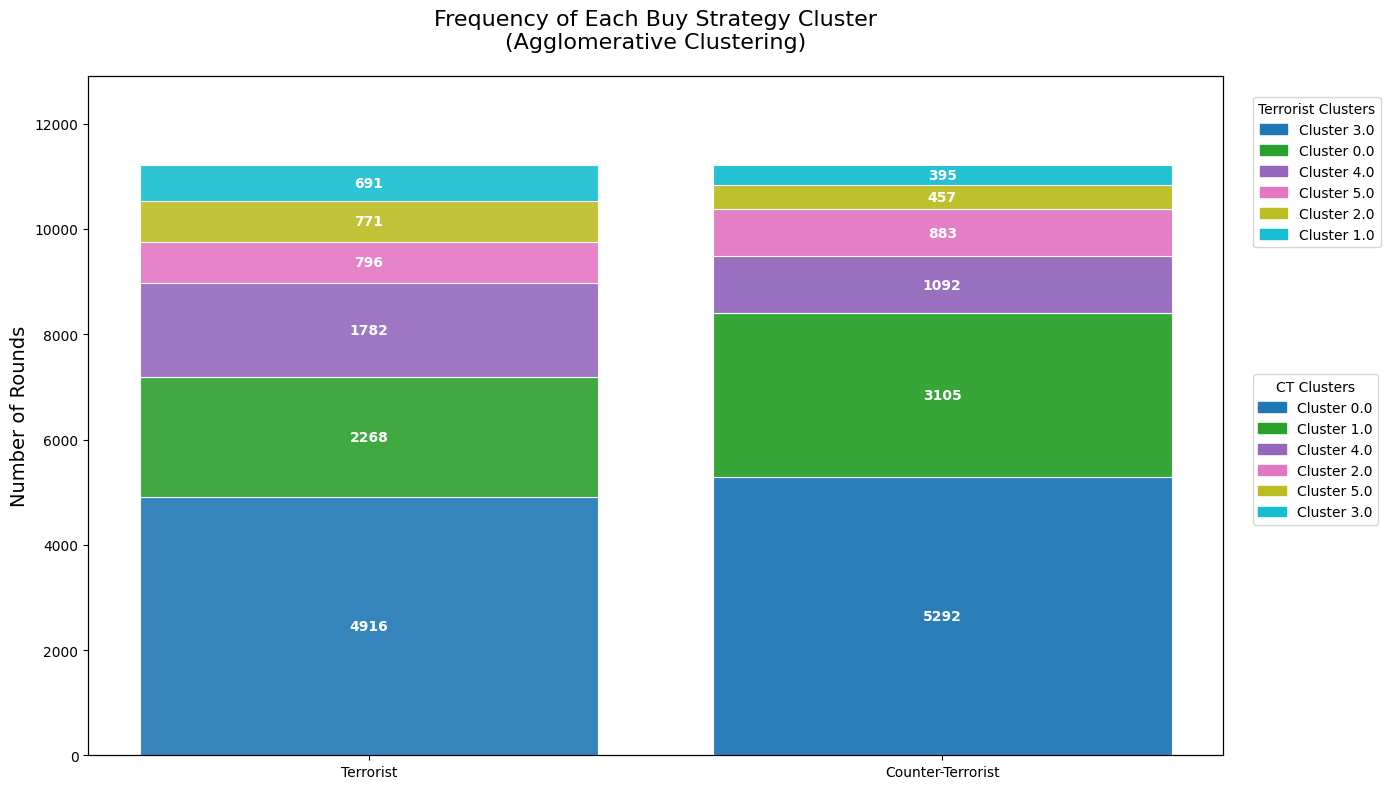

In [26]:


def plot_stacked_frequency_agg_separate_legends(t_report_agg, ct_report_agg):
    # Use agglomerative reports (exact cluster_ids preserved)
    t_df = t_report_agg.to_pandas()
    ct_df = ct_report_agg.to_pandas()
    
    # Normalize utility by dividing by 4 (max 4 grenades per player)
    if 'total_util' in t_df.columns:
        t_df['total_util_norm'] = t_df['total_util'] / 4
        ct_df['total_util_norm'] = ct_df['total_util'] / 4
    
    # Sort by times_used descending (most frequent at bottom)
    t_df = t_df.sort_values("times_used", ascending=False).reset_index(drop=True)
    ct_df = ct_df.sort_values("times_used", ascending=False).reset_index(drop=True)
    
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Color map – shared across both sides for visual consistency
    max_clusters = max(len(t_df), len(ct_df))
    colors = plt.cm.tab10(np.linspace(0, 1, max_clusters))
    
    # Terrorist stacked bar
    bottom_t = 0
    t_handles = []
    for i, row in t_df.iterrows():
        cluster_id = row['cluster_id']  # exact ID from agglomerative table
        height = row['times_used']
        color = colors[i % len(colors)]
        bar = ax.bar("Terrorist", height, bottom=bottom_t, color=color, 
                     alpha=0.9, edgecolor='white', linewidth=0.8)
        ax.text(0, bottom_t + height/2, f"{int(height)}", 
                ha='center', va='center', color='white', fontweight='bold', fontsize=10)
        t_handles.append(plt.Rectangle((0,0),1,1, color=color, label=f"Cluster {cluster_id}"))
        bottom_t += height
    
    # Counter-Terrorist stacked bar
    bottom_ct = 0
    ct_handles = []
    for i, row in ct_df.iterrows():
        cluster_id = row['cluster_id']  # exact ID from agglomerative table
        height = row['times_used']
        color = colors[i % len(colors)]
        bar = ax.bar("Counter-Terrorist", height, bottom=bottom_ct, color=color, 
                     alpha=0.95, edgecolor='white', linewidth=0.8)
        ax.text(1, bottom_ct + height/2, f"{int(height)}", 
                ha='center', va='center', color='white', fontweight='bold', fontsize=10)
        ct_handles.append(plt.Rectangle((0,0),1,1, color=color, label=f"Cluster {cluster_id}"))
        bottom_ct += height
    
    # Labels and title
    ax.set_ylabel("Number of Rounds", fontsize=14)
    ax.set_title("Frequency of Each Buy Strategy Cluster\n(Agglomerative Clustering)", fontsize=16, pad=20)
    ax.set_ylim(0, max(t_df['times_used'].sum(), ct_df['times_used'].sum()) * 1.15)
    
    # Two separate legends
    ax.legend(handles=t_handles, title="Terrorist Clusters", 
              bbox_to_anchor=(1.02, 0.98), loc='upper left', fontsize=10)
    
    ax2 = ax.twinx()  # invisible twin axis just for CT legend
    ax2.set_yticks([])
    ax2.legend(handles=ct_handles, title="CT Clusters", 
               bbox_to_anchor=(1.02, 0.45), loc='center left', fontsize=10)
    
    plt.tight_layout()
    plt.savefig("Figure_10_Stacked_Frequency_Agglomerative_Separate_Legends.png", dpi=300, bbox_inches='tight')
    plt.show()

# Run after your agg_analyze_side calls
plot_stacked_frequency_agg_separate_legends(t_report, ct_report)

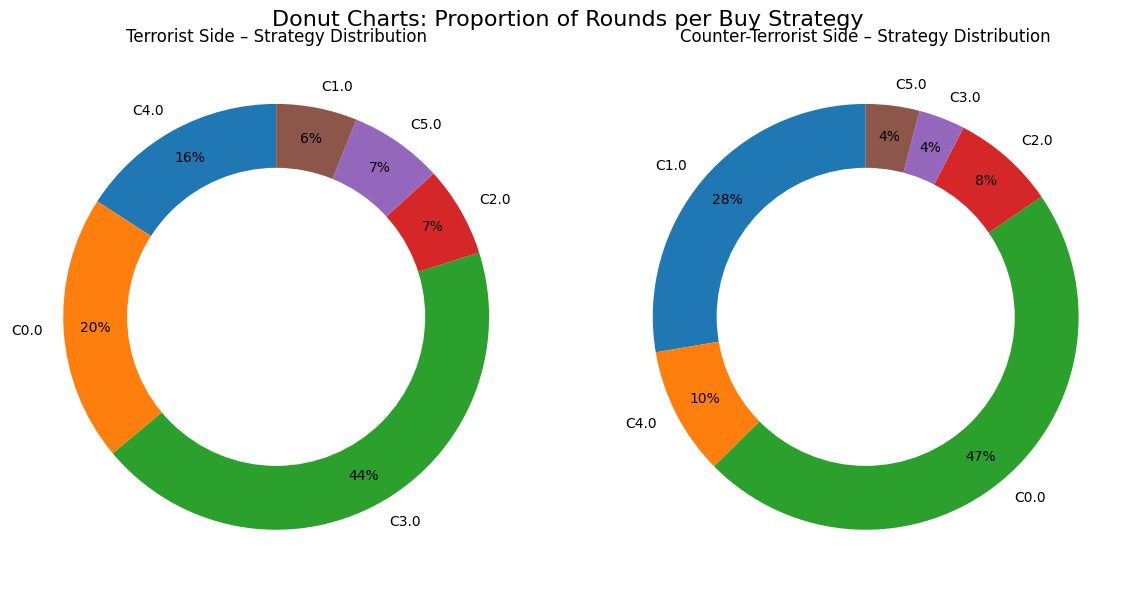

In [27]:
def donut_charts_per_side(t_report, ct_report):
    t_df = t_report.to_pandas()
    ct_df = ct_report.to_pandas()
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    
    # Terrorist
    wedges, texts, autotexts = ax1.pie(t_df['times_used'], labels=[f"C{row['cluster_id']}" for _, row in t_df.iterrows()],
                                       autopct='%1.0f%%', startangle=90, pctdistance=0.85, 
                                       colors=plt.cm.tab10(range(len(t_df))))
    centre_circle = plt.Circle((0,0),0.70,fc='white')
    ax1.add_artist(centre_circle)
    ax1.set_title("Terrorist Side – Strategy Distribution")
    
    # Counter-Terrorist
    wedges, texts, autotexts = ax2.pie(ct_df['times_used'], labels=[f"C{row['cluster_id']}" for _, row in ct_df.iterrows()],
                                       autopct='%1.0f%%', startangle=90, pctdistance=0.85, 
                                       colors=plt.cm.tab10(range(len(ct_df))))
    centre_circle = plt.Circle((0,0),0.70,fc='white')
    ax2.add_artist(centre_circle)
    ax2.set_title("Counter-Terrorist Side – Strategy Distribution")
    
    plt.suptitle("Donut Charts: Proportion of Rounds per Buy Strategy", fontsize=16)
    plt.tight_layout()
    plt.savefig("donut_frequency.png", dpi=300, bbox_inches='tight')
    plt.show()

donut_charts_per_side(t_report, ct_report)

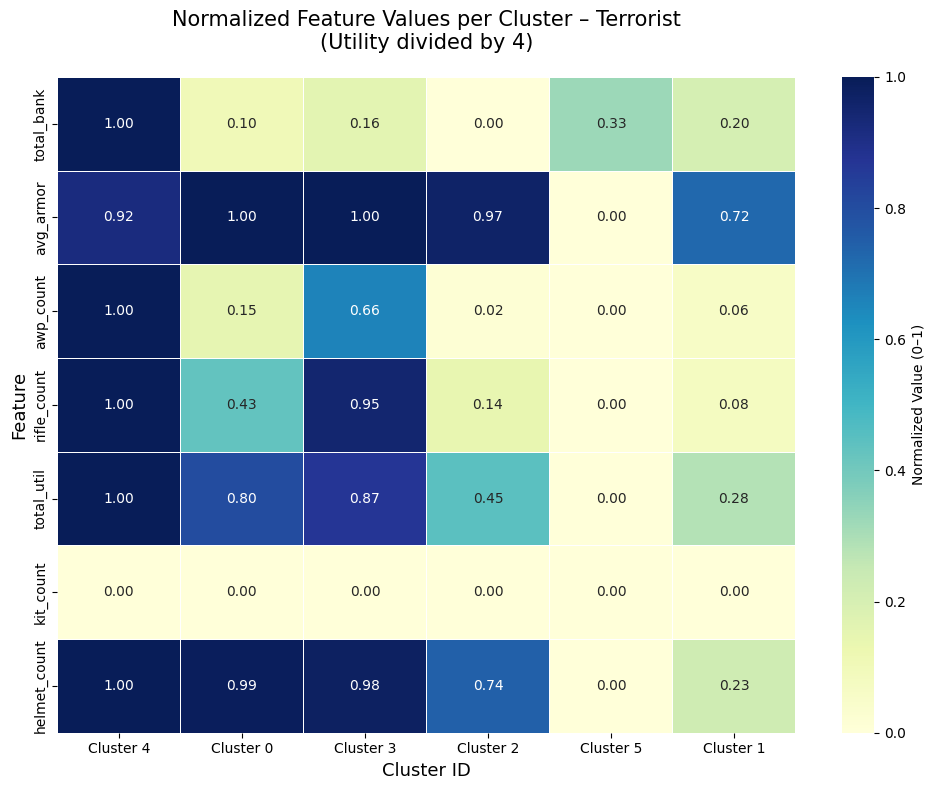

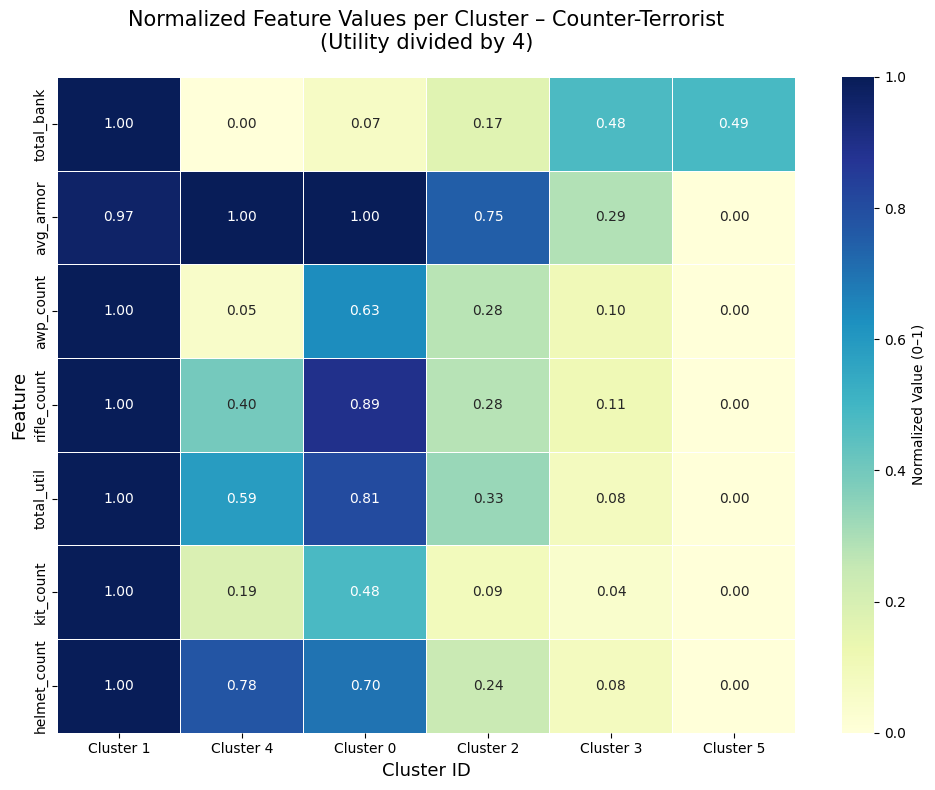

In [28]:


def plot_normalized_heatmap(report_df, side_name="Side"):
    df = report_df.to_pandas()
    
    # Divide utility by 4
    if 'total_util' in df.columns:
        df['total_util'] = df['total_util'] / 4
    
    features = ['total_bank', 'avg_armor', 'awp_count', 'rifle_count', 
                'total_util', 'kit_count', 'helmet_count']
    
    # Normalize to 0-1
    norm = df[features].apply(lambda x: (x - x.min()) / (x.max() - x.min() + 1e-8))
    norm.index = [f"Cluster {cid}" for cid in df['cluster_id']]
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(norm.T, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=0.5,
                cbar_kws={'label': 'Normalized Value (0–1)'})
    plt.title(f"Normalized Feature Values per Cluster – {side_name}\n"
              "(Utility divided by 4)", fontsize=15, pad=20)
    plt.ylabel("Feature", fontsize=13)
    plt.xlabel("Cluster ID", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"heatmap_normalized_{side_name.lower()}.png", dpi=300, bbox_inches='tight')
    plt.show()

# Run
plot_normalized_heatmap(t_report, "Terrorist")
plot_normalized_heatmap(ct_report, "Counter-Terrorist")

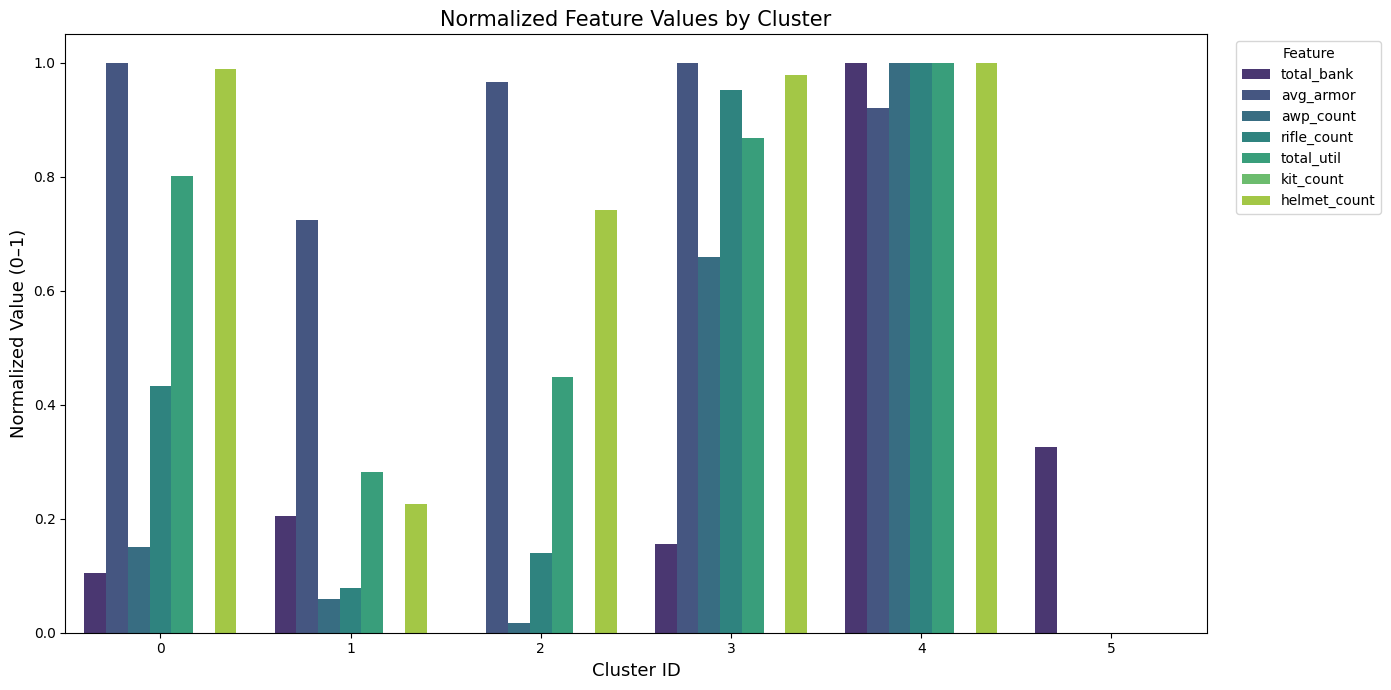

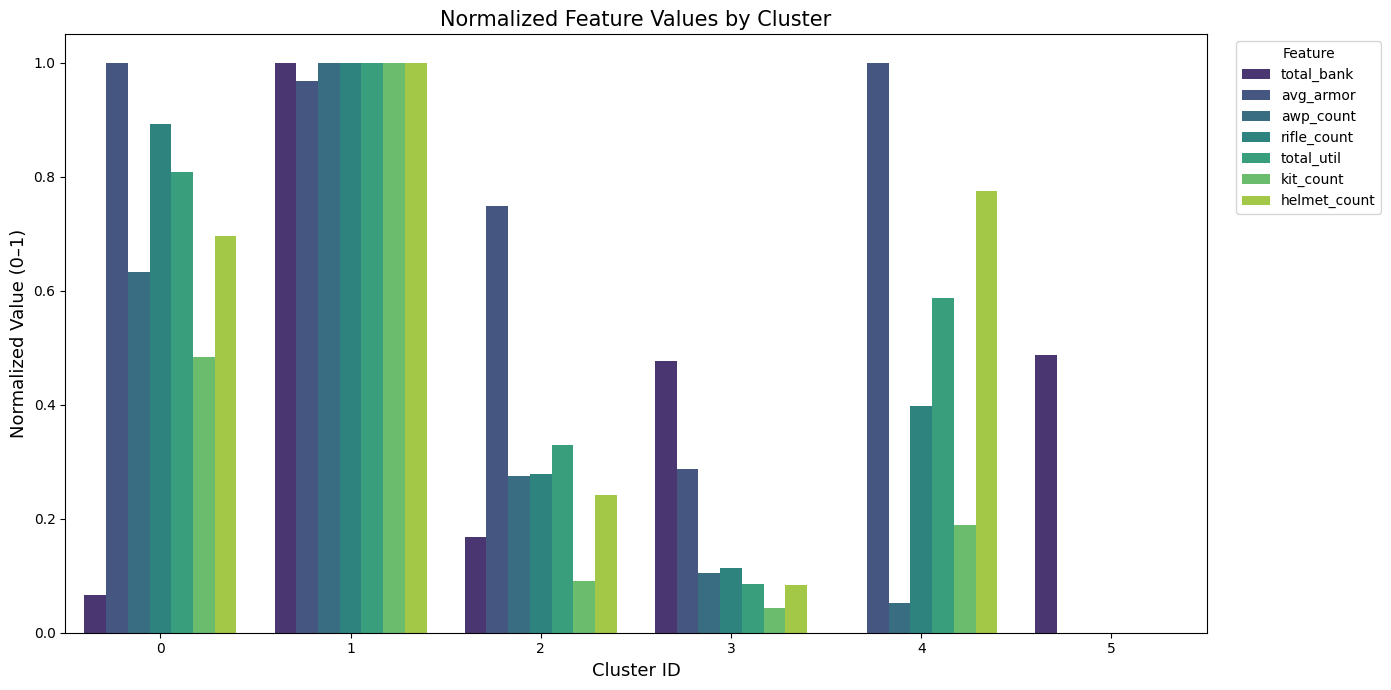

In [29]:
def grouped_bar_all_features(report_df, side_name="Side"):
    df = report_df.to_pandas()
    
    if 'total_util' in df.columns:
        df['total_util'] = df['total_util'] / 4
    
    features = ['total_bank', 'avg_armor', 'awp_count', 'rifle_count', 
                'total_util', 'kit_count', 'helmet_count']
    
    # Normalize
    norm = df[features].apply(lambda x: (x - x.min()) / (x.max() - x.min() + 1e-8))
    norm['cluster_id'] = df['cluster_id']
    
    melted = norm.melt(id_vars='cluster_id', var_name='Feature', value_name='Normalized Value')
    
    plt.figure(figsize=(14, 7))
    sns.barplot(data=melted, x='cluster_id', y='Normalized Value', hue='Feature', palette='viridis')
    plt.title(f"Normalized Feature Values by Cluster", fontsize=15)
    plt.xlabel("Cluster ID", fontsize=13)
    plt.ylabel("Normalized Value (0–1)", fontsize=13)
    plt.legend(title="Feature", bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(f"grouped_bar_{side_name.lower()}.png", dpi=300, bbox_inches='tight')
    plt.show()

grouped_bar_all_features(t_report, "Terrorist")
grouped_bar_all_features(ct_report, "Counter-Terrorist")

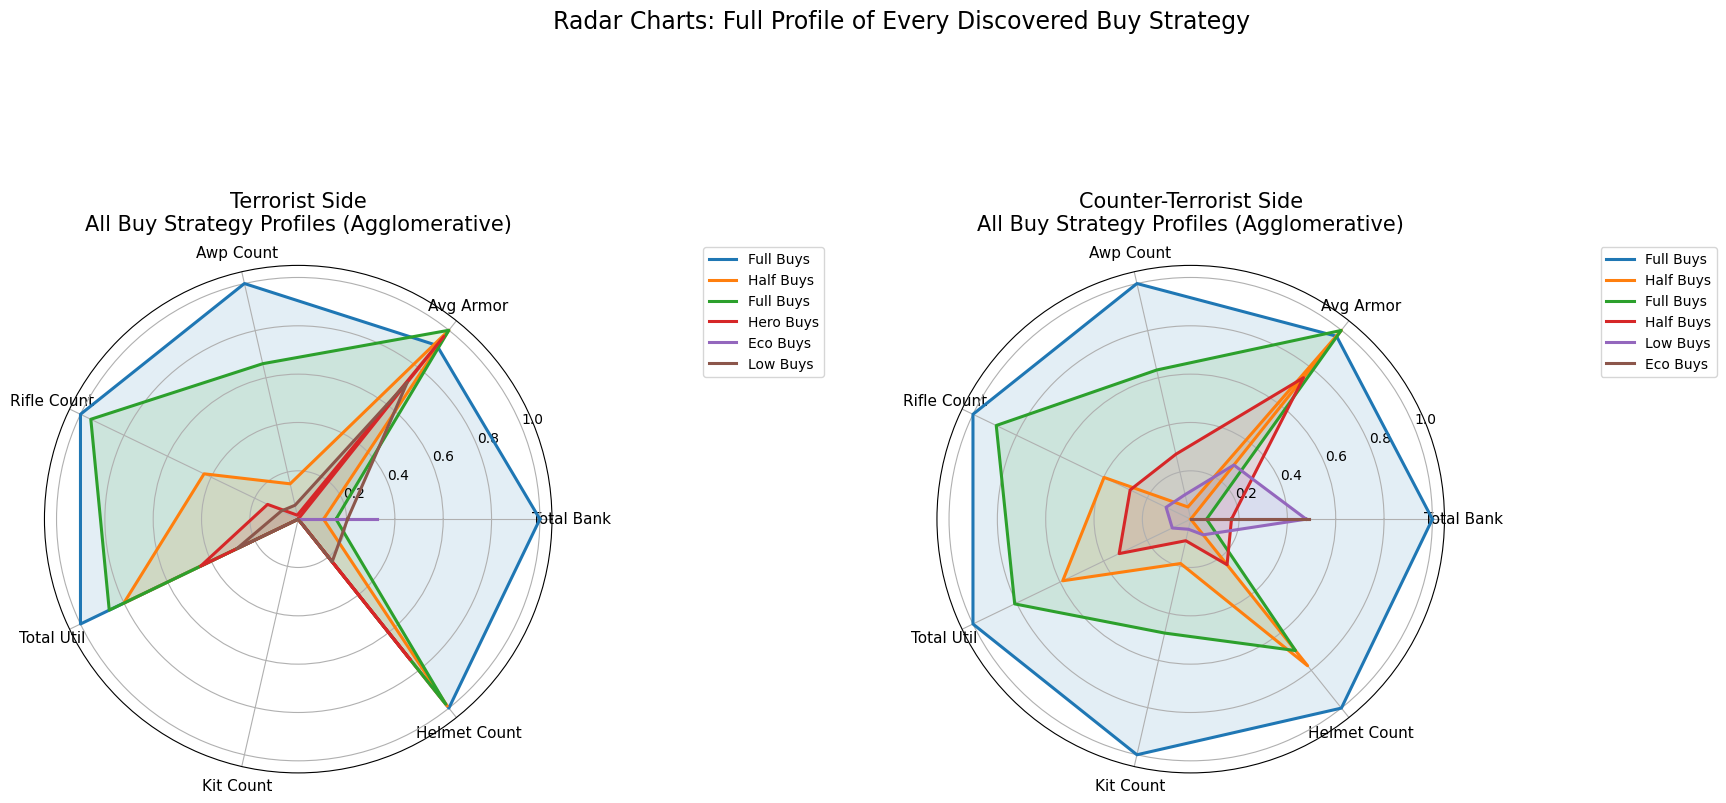

In [30]:


# Define the new cluster labels from user input
t_cluster_labels = {
    0: "Half Buys",
    1: "Low Buys",
    2: "Hero Buys",
    3: "Full Buys",
    4: "Full Buys",
    5: "Eco Buys"
}

ct_cluster_labels = {
    0: "Full Buys",
    1: "Full Buys",
    2: "Half Buys",
    3: "Low Buys",
    4: "Half Buys",
    5: "Eco Buys"
}

def plot_radar_all_clusters(t_report_agg, ct_report_agg):
    features = ['total_bank', 'avg_armor', 'awp_count', 'rifle_count', 
                'total_util', 'kit_count', 'helmet_count']
    
    # Terrorist - all clusters
    t_all = t_report_agg.to_pandas()
    if 'total_util' in t_all.columns:
        t_all['total_util'] = t_all['total_util'] / 4
    t_norm = t_all[features].apply(lambda x: (x - x.min()) / (x.max() - x.min() + 1e-8), axis=0)
    
    # Counter-Terrorist - all clusters
    ct_all = ct_report_agg.to_pandas()
    if 'total_util' in ct_all.columns:
        ct_all['total_util'] = ct_all['total_util'] / 4
    ct_norm = ct_all[features].apply(lambda x: (x - x.min()) / (x.max() - x.min() + 1e-8), axis=0)
    
    categories = [f.replace('_', ' ').title() for f in features]
    N = len(categories)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    
    fig, axs = plt.subplots(1, 2, figsize=(18, 9), subplot_kw=dict(polar=True))
    
    # Terrorist Side
    ax = axs[0]
    for idx, row in t_norm.iterrows():
        cluster_id = t_all['cluster_id'].iloc[idx]
        label = t_cluster_labels.get(cluster_id, f"Cluster {cluster_id}")  # Use new label
        values = row.tolist() + row.tolist()[:1]
        ax.plot(angles, values, linewidth=2.2, linestyle='solid', label=label)
        ax.fill(angles, values, alpha=0.12)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=11)
    ax.set_title("Terrorist Side\nAll Buy Strategy Profiles (Agglomerative)", fontsize=15, pad=25)
    ax.legend(loc='upper right', bbox_to_anchor=(1.55, 1.05), fontsize=10)
    
    # Counter-Terrorist Side
    ax = axs[1]
    for idx, row in ct_norm.iterrows():
        cluster_id = ct_all['cluster_id'].iloc[idx]
        label = ct_cluster_labels.get(cluster_id, f"Cluster {cluster_id}")  # Use new label
        values = row.tolist() + row.tolist()[:1]
        ax.plot(angles, values, linewidth=2.2, linestyle='solid', label=label)
        ax.fill(angles, values, alpha=0.12)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=11)
    ax.set_title("Counter-Terrorist Side\nAll Buy Strategy Profiles (Agglomerative)", fontsize=15, pad=25)
    ax.legend(loc='upper right', bbox_to_anchor=(1.55, 1.05), fontsize=10)
    
    plt.suptitle("Radar Charts: Full Profile of Every Discovered Buy Strategy", fontsize=17, y=1.02)
    plt.tight_layout()
    plt.savefig("Figure_9_Radar_All_Clusters_Agglomerative.png", dpi=300, bbox_inches='tight')
    plt.show()

# Run this after your agg_analyze_side calls
plot_radar_all_clusters(t_report, ct_report)

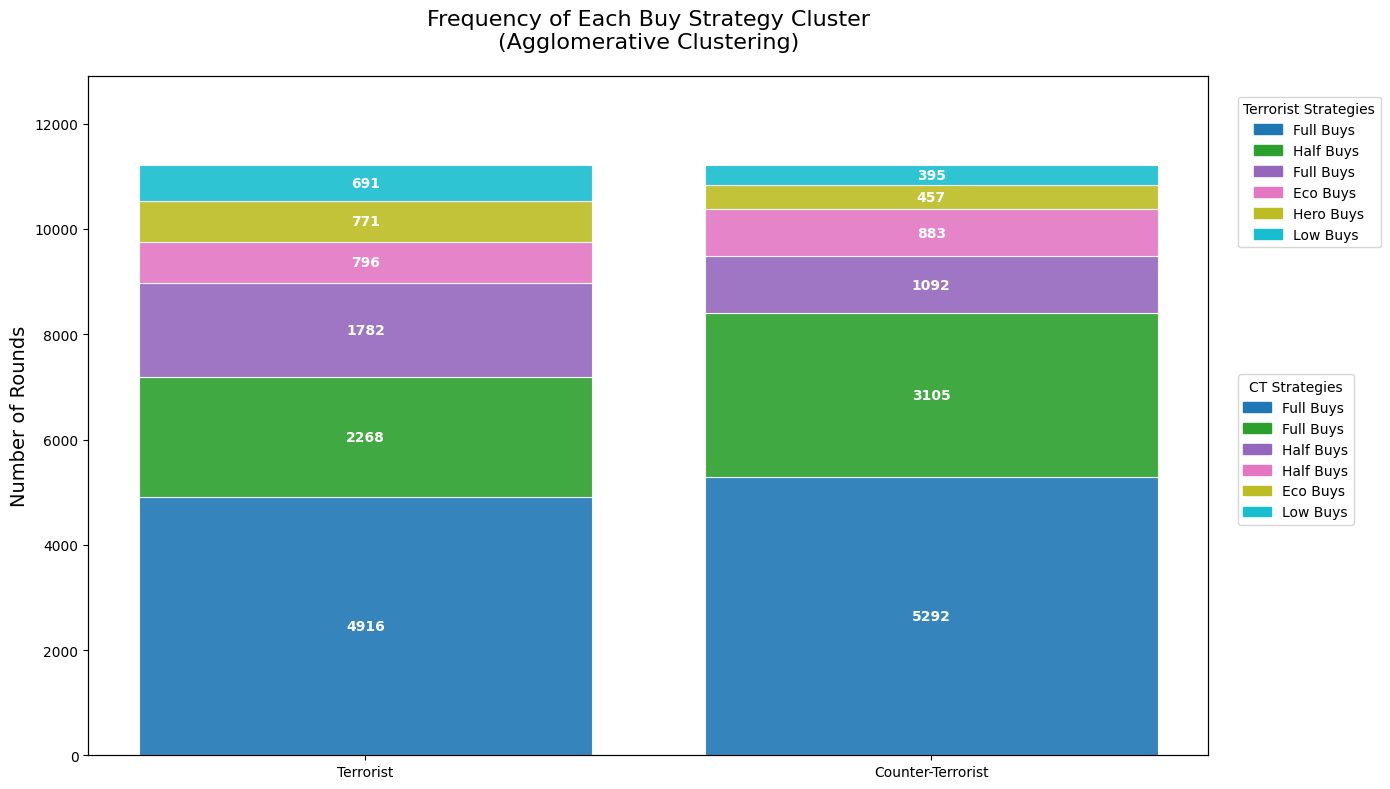

In [31]:
def plot_stacked_frequency_agg_separate_legends(t_report_agg, ct_report_agg):
    # Convert to pandas – clusters are already in order from your agg_analyze_side
    t_df = t_report_agg.to_pandas()
    ct_df = ct_report_agg.to_pandas()
    
    # Normalize utility by dividing by 4
    if 'total_util' in t_df.columns:
        t_df['total_util_norm'] = t_df['total_util'] / 4
        ct_df['total_util_norm'] = ct_df['total_util'] / 4
    
    # Sort by times_used descending
    t_df = t_df.sort_values("times_used", ascending=False).reset_index(drop=True)
    ct_df = ct_df.sort_values("times_used", ascending=False).reset_index(drop=True)
    
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Color map
    max_clusters = max(len(t_df), len(ct_df))
    colors = plt.cm.tab10(np.linspace(0, 1, max_clusters))
    
    # Terrorist stacked bar
    bottom_t = 0
    t_handles = []
    for i, row in t_df.iterrows():
        cluster_id = row['cluster_id']
        label = t_cluster_labels.get(cluster_id, f"Cluster {cluster_id}")  # Use new label
        height = row['times_used']
        color = colors[i % len(colors)]
        ax.bar("Terrorist", height, bottom=bottom_t, color=color, 
               alpha=0.9, edgecolor='white', linewidth=0.8)
        ax.text(0, bottom_t + height/2, f"{int(height)}", 
                ha='center', va='center', color='white', fontweight='bold', fontsize=10)
        t_handles.append(plt.Rectangle((0,0),1,1, color=color, label=label))
        bottom_t += height
    
    # Counter-Terrorist stacked bar
    bottom_ct = 0
    ct_handles = []
    for i, row in ct_df.iterrows():
        cluster_id = row['cluster_id']
        label = ct_cluster_labels.get(cluster_id, f"Cluster {cluster_id}")  # Use new label
        height = row['times_used']
        color = colors[i % len(colors)]
        ax.bar("Counter-Terrorist", height, bottom=bottom_ct, color=color, 
               alpha=0.9, edgecolor='white', linewidth=0.8)
        ax.text(1, bottom_ct + height/2, f"{int(height)}", 
                ha='center', va='center', color='white', fontweight='bold', fontsize=10)
        ct_handles.append(plt.Rectangle((0,0),1,1, color=color, label=label))
        bottom_ct += height
    
    # Labels & title
    ax.set_ylabel("Number of Rounds", fontsize=14)
    ax.set_title("Frequency of Each Buy Strategy Cluster\n(Agglomerative Clustering)", fontsize=16, pad=20)
    ax.set_ylim(0, max(t_df['times_used'].sum(), ct_df['times_used'].sum()) * 1.15)
    
    # Two separate legends with new labels
    ax.legend(handles=t_handles, title="Terrorist Strategies", 
              bbox_to_anchor=(1.02, 0.98), loc='upper left', fontsize=10)
    
    ax2 = ax.twinx()  # invisible twin for CT legend
    ax2.set_yticks([])
    ax2.legend(handles=ct_handles, title="CT Strategies", 
               bbox_to_anchor=(1.02, 0.45), loc='center left', fontsize=10)
    
    plt.tight_layout()
    plt.savefig("Figure_10_Stacked_Frequency_Agglomerative_Separate_Legends.png", dpi=300, bbox_inches='tight')
    plt.show()

# Run after your agg_analyze_side calls
plot_stacked_frequency_agg_separate_legends(t_report, ct_report)